# Do borrowed ideas stick when grafted locally? — RQ2-D2 host-entry test (demo)

This notebook is a runnable walk-through of the **RQ2-D2 host-entry experiment**. The question: when a research
concept *c* first appears in a subfield *d* outside its origin subfield (a **host entry** in year *e*), does newcomer
uptake in *d* over the next five years depend on

* **anchoring `A_cont`** (the *grafting* story): the entry papers' partner concepts are already native to the host.
  It is measured as the partners' pre-entry share of host-*d* papers, from OpenAlex subfield × 5-year-block profiles;
* **co-transfer `CT`** (the *toolkit* story): the concept arrives together with its origin companions. It is the share
  of partners that were companions of *c* in its origin subfield in [e-5, e-1].

The outcome `Y_strict` counts host-*d* papers of *c* in [e+1, e+5] written by author-disjoint newcomers. It is modelled
with **PPML** (Poisson pseudo-maximum likelihood), high-dimensional fixed effects, an offset log(n_entry_papers), and
concept-clustered CRV1 standard errors. The pre-registered decision rule is **GRAFTING / TOOLKIT / BOTH / NEITHER**,
applied to Holm-adjusted p-values over {b_A, b_CT}.

The original pipeline (`method.py`, stages 0–16) starts from a hydrated 426-concept OpenAlex corpus of several GB. The
demo starts from the per-event feature table that stages 1–6 produce (`screen_events_with_outcomes.parquet`) and runs
the analysis stages on a **100-event subset** (13 concepts):

| Original stage | What this notebook runs |
|---|---|
| 7 — models | primary / co-primary / coarse FE PPML fits, wild-cluster score bootstrap, Holm decision, pyfixest cross-check |
| 9 — placebo | the within-cell **label shuffle** placebo. The nativeness-permutation placebo needs the raw corpus and is skipped |
| 12 — out-of-sample | grouped-by-concept 5-fold Poisson prediction check (M0 controls-only vs M1 = M0 + A + CT) |

The functions are copied from the artifact's `src/ppml.py`, `src/models.py`, `src/placebo.py` and
`src/assemble_out.py` with only small notebook adaptations. **Caveat:** 100 events cannot identify concept × year fixed
effects well, so the demo coefficients are noisy. The last section puts them next to the full-run (1,740-event)
headline numbers.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

# loguru, orjson, pyfixest — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3', 'orjson==3.11.3', 'pyfixest==0.60.0')

## Imports

These are the import blocks of `method.py` and of the `src/` modules used below (`ppml`, `models`, `placebo`,
`assemble_out`). The notebook adds `matplotlib` for the plots and `types` to rebuild the module namespaces.

In [2]:
from __future__ import annotations

# method.py
import argparse
import json
import sys
import time
from pathlib import Path

import pandas as pd
from loguru import logger

# src/models.py, src/placebo.py, src/assemble_out.py, src/config.py
import hashlib
import math
import os
import warnings
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import orjson
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# notebook additions
import types
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load the demo data

`mini_demo_data.json` holds 100 host-entry events copied row-for-row from the artifact's
`results/screen_events_with_outcomes.parquet`. It also holds the full-run headline results, which the last section
uses for comparison. The loader tries GitHub first and then falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_desxWCcMY1R1/round-3/experiment-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("events:", data["metadata"]["n_events"], "| concepts:", data["metadata"]["n_concepts"])

100 screen-fold MAIN kw5 host-entry events (concept c first appears in non-origin subfield d in year e) from 13 concepts, chosen so every fixed-effect spec of stage 7 can be fitted. Each row holds the W1 features (A_cont anchoring, CT co-transfer, controls) and the W2 outcomes (Y_strict etc.). Columns are exactly those of the original parquet.
events: 100 | concepts: 13


## Configuration

These are the tunable parameters. The original values are in the comments. The resampling counts are the only settings
that drive runtime; the sample size is fixed by the 100 events in the demo file.

In [5]:
SEED = 20260929            # config.SEED (unchanged)
WILD_REPS = 999            # wild cluster score bootstrap reps per coefficient   (original: 999)
N_SHUFFLES = 50            # stage-9 within-cell label-shuffle draws           (original: 50)
OOS_BOOT_REPS = 1000       # stage-12 concept-bootstrap reps for the deviance CI (original: 1000)
RUN_PYFIXEST_CROSSCHECK = True  # stage 7 cross-checks the own PPML against pyfixest.fepois (original: True)
N_WORKERS = max(1, min(4, os.cpu_count() or 1))  # original: config.detect_cpus() (all cores)

RESULTS = Path("results")   # original: <artifact>/results
RESULTS.mkdir(parents=True, exist_ok=True)

### The event table

This replaces `pd.read_parquet(RESULTS / "screen_events_with_outcomes.parquet")`. Each row is one host entry
(concept `concept_id`, origin subfield `o`, host subfield `d`, entry year `e`) and has these column groups:
* W1 features: `A_cont`, `CT`, controls such as `prox_od`, `RD`, `cov`, …;
* sample flags: `arm`, `fold`, `kw5`, `MAIN`;
* W2 outcomes: `Y_strict`, `Y_lenient`, `Y_all`, `EST_bin`.

In [6]:
df = pd.DataFrame(data["datasets"][0]["examples"])
print(df.shape)
df[["concept_id", "o", "d", "e", "n_entry_papers", "A_cont", "CT", "Y_strict", "Y_all", "field_group"]].head(8)

(100, 83)


,concept_id,o,d,e,n_entry_papers,A_cont,CT,Y_strict,Y_all,field_group
0,c_9e3bad270e4c,3106,2202,2017,1,0.032141,0.400000,0,0,Physics/Astro
1,c_9e3bad270e4c,3106,2505,2017,1,0.079859,0.857143,0,1,Physics/Astro
2,c_9e3bad270e4c,3106,3107,2017,1,0.127054,1.000000,2,6,Physics/Astro
3,c_ef7889a4d23e,2505,2211,2014,2,0.027187,0.842105,1,1,other
4,c_ef7889a4d23e,2505,2503,2014,1,0.010848,0.750000,0,0,other
5,c_70af732266c6,3107,1702,2015,1,0.150584,0.636364,0,2,Physics/Astro
6,c_70af732266c6,3107,2504,2015,1,0.062000,0.470588,4,7,Physics/Astro
7,c_2fc072066f34,1702,1707,2016,1,0.018446,1.000000,1,1,CS


## Stage 7a — the PPML estimator (`src/ppml.py`, verbatim)

This is a fast Poisson pseudo-ML with two or three high-dimensional fixed effects:

* `_prune` iteratively drops singleton FE levels and FE levels whose outcome is all zero (separation);
* `_demean` projects exactly onto the complement of the FE space, using a sparse LU of D'WD;
* `fit` runs IRLS and returns CRV1 cluster-robust SEs with pyfixest's small-sample factor. FE levels nested in clusters
  are not counted in that factor;
* `wild_score_test` is the Kline–Santos wild cluster (Rademacher) score bootstrap for H0: b = 0.

In [7]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


def wild_score_test(y, X_restricted, x2, fes, offset, cluster, rng, reps: int = 199) -> float | None:
    """Kline-Santos wild cluster (Rademacher) score bootstrap for H0: coefficient on x2 = 0."""
    r = fit(y, X_restricted, fes, offset, cluster)
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fes_k = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    Xall = np.column_stack([x2[keep], X_restricted[keep]])
    D = _demean(Xall, mu, fes_k)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    s = np.bincount(r["cl"], weights=x2r * (r["y"] - mu))
    if len(s) < 2 or (s ** 2).sum() == 0:
        return None
    T = s.sum() ** 2 / (s ** 2).sum()
    eps = rng.choice([-1.0, 1.0], size=(reps, len(s)))
    Ts = (eps @ s) ** 2 / (s ** 2).sum()
    return float((1 + (Ts >= T).sum()) / (reps + 1))


# notebook: expose the functions under the module name the original code uses (ppml.fit, ...)
ppml = types.SimpleNamespace(fit=fit, wild_score_test=wild_score_test, _prune=_prune, _demean=_demean)

## Stage 7b — sample, fixed-effect specs and one PPML fit (`src/models.py`)

* `primary_sample` keeps the main-arm, screen-fold, MAIN, kw5 events (≥ 5 distinct partners) and builds the FE codes.
* The four pre-declared FE specs are:
  * **primary**: concept×e + d×e;
  * **secondary**: concept + e + d. This spec became *co-primary* in the full run through pre-declared fallback 3,
    because the primary spec kept < 30 % of events;
  * **coarse_cx2y**: concept × 2-year bin + d×e;
  * **c_plus_dxe**: concept + d×e.
* `fit_one` turns coefficients into IRR per SD and per 0.1, with t(G-1) CIs. It can also add wild bootstrap p-values.

The only change from the original is `reps=999` → `reps=WILD_REPS`.

In [8]:
A_VAR = "A_cont"  # primary anchoring measure after the pre-declared nativeness fallback (deviations.md #1)
CT_VAR = "CT"
EVENT_CONTROLS = ["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share",
                  "abstract_share"]
SECONDARY_EXTRA = ["mom_d", "log_centrality", "log_W1"]


def primary_sample(df: pd.DataFrame, pop: str = "MAIN", fold: str = "screen") -> pd.DataFrame:
    s = df[(df.arm == "main") & (df.fold == fold) & df.kw5 & df[pop]].copy()
    need = [A_VAR, CT_VAR] + EVENT_CONTROLS + SECONDARY_EXTRA
    s = s.dropna(subset=[c for c in need if c in s.columns])
    s["cxe"] = pd.factorize(s.concept_id + "_" + s.e.astype(str))[0]
    s["dxe"] = pd.factorize(s.d.astype(str) + "_" + s.e.astype(str))[0]
    s["cfe"] = pd.factorize(s.concept_id)[0]
    s["efe"] = pd.factorize(s.e.astype(str))[0]
    s["dfe"] = pd.factorize(s.d.astype(str))[0]
    s["cx2"] = pd.factorize(s.concept_id + "_" + ((s.e - 2005) // 2).astype(str))[0]
    s["offset"] = np.log(s.n_entry_papers.astype(float))
    return s.reset_index(drop=True)


FE_SPECS = {"primary": ["cxe", "dxe"], "secondary": ["cfe", "efe", "dfe"],
            "coarse_cx2y": ["cx2", "dxe"],  # pre-declared coarsening: concept x 2-year entry bin + d x e
            "c_plus_dxe": ["cfe", "dxe"]}   # pre-declared alternative: concept + d x e


def fe_arrays(s: pd.DataFrame, spec: str) -> list[np.ndarray]:
    return [s[c].to_numpy() for c in FE_SPECS[spec]]


def fit_one(s: pd.DataFrame, y: str, xvars: list[str], spec: str = "primary", wild: bool = False,
            wild_vars: tuple = (), rng=None) -> dict | None:
    X = s[xvars].to_numpy(float)
    fes = fe_arrays(s, spec)
    yv = s[y].to_numpy(float)
    r = ppml.fit(yv, X, fes, s.offset.to_numpy(), s.concept_id.to_numpy(), maxit=500, tol=1e-12)
    if r is None:
        return None
    keep = r["keep"]
    G = r["G"]
    out = {"spec": spec, "y": y, "x": xvars, "n_input": int(len(s)), "n_retained": int(r["n"]), "G": int(G),
           "retained_share": float(r["n"] / len(s)), "coef": {}, "se": {}, "p": {}, "irr_sd": {}, "irr_01": {},
           "ci_irr_sd": {}, "sd_retained": {}}
    # singleton / separation accounting for the first FE dimension
    cells = pd.Series(fes[0]).value_counts()
    out["n_nonsingleton_fe0_cells"] = int((cells >= 2).sum())
    out["n_fe0_cells"] = int(len(cells))
    out["events_in_nonsingleton_fe0_cells"] = int(cells[cells >= 2].sum())
    tq = stats.t.ppf(0.975, G - 1)
    for i, v in enumerate(xvars):
        b, se = float(r["coef"][i]), float(r["se"][i])
        sd = float(s.loc[keep, v].std())
        tstat = b / se if se > 0 else np.nan
        out["coef"][v], out["se"][v] = b, se
        out["p"][v] = float(2 * stats.t.sf(abs(tstat), G - 1)) if se > 0 else np.nan
        out["sd_retained"][v] = sd
        out["irr_sd"][v] = float(np.exp(b * sd))
        out["irr_01"][v] = float(np.exp(b * 0.1))
        out["ci_irr_sd"][v] = [float(np.exp((b - tq * se) * sd)), float(np.exp((b + tq * se) * sd))]
    out["deviance"] = float(2 * np.sum(np.where(r["y"] > 0, r["y"] * np.log(np.where(r["y"] > 0, r["y"], 1) / r["mu"]),
                                                 0) - (r["y"] - r["mu"])))
    if wild:
        rng = rng or np.random.default_rng(SEED)
        out["p_wild"] = {}
        for v in wild_vars:
            j = xvars.index(v)
            Xr = np.delete(X, j, axis=1)
            out["p_wild"][v] = ppml.wild_score_test(yv, Xr, X[:, j], fes, s.offset.to_numpy(), s.concept_id.to_numpy(),
                                                    rng, reps=WILD_REPS)
    return out

## Stage 7c — decision rule, pyfixest cross-check, LPM (`src/models.py`)

* `holm` adjusts the two p-values (b_A, b_CT) with Holm's step-down procedure.
* `decide` applies the pre-registered reading: **GRAFTING** if b_A > 0 and significant while b_CT is not significantly
  > 0; **TOOLKIT** the other way round; **BOTH**; or **NEITHER**.
* `pyfixest_crosscheck` refits the primary model with `pyfixest.fepois` on the pruned sample. Coefficients should
  agree to 1e-4.
* `lpm_fe` is the linear probability model for the binary establishment outcome `EST_bin`.

In [9]:
def holm(pvals: dict) -> dict:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    adj, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        adj[k] = run
    return adj


def decide(res: dict) -> dict:
    bA, bC = res["coef"][A_VAR], res["coef"][CT_VAR]
    h = holm({A_VAR: res["p"][A_VAR], CT_VAR: res["p"][CT_VAR]})
    sigA, sigC = h[A_VAR] < 0.05, h[CT_VAR] < 0.05
    if sigA and bA > 0 and not (sigC and bC > 0):
        reading = "GRAFTING"
    elif sigC and bC > 0 and not sigA:
        reading = "TOOLKIT"
    elif sigA and bA > 0 and sigC and bC > 0:
        reading = "BOTH"
    else:
        reading = "NEITHER"
    notes = []
    if sigA and bA < 0:
        notes.append("significant NEGATIVE anchoring coefficient (anchoring penalty)")
    if sigC and bC < 0:
        notes.append("significant NEGATIVE co-transfer coefficient (package penalty)")
    if sigC and bC > 0 and sigA and bA < 0:
        notes.append("co-transfer premium with an anchoring penalty")
    return {"reading": reading, "holm_p": h, "notes": notes}


def pyfixest_crosscheck(s: pd.DataFrame, y: str, xvars: list[str]) -> dict:
    """pyfixest.fepois on the sample retained by our iterated singleton/separation pruning, tight tolerances.
    (pyfixest's own pruning is not iterated, so on the unpruned sample it keeps extra singletons: same coefficients,
    different N and small-sample factor.)"""
    import pyfixest as pf
    r_own = fit_one(s, y, xvars, "primary")
    r_raw = ppml.fit(s[y].to_numpy(float), s[xvars].to_numpy(float), fe_arrays(s, "primary"), s.offset.to_numpy(),
                     s.concept_id.to_numpy())
    d = s[r_raw["keep"]].copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = pf.fepois(f"{y} ~ {' + '.join(xvars)} | cxe + dxe", data=d, offset="offset", vcov={"CRV1": "concept_id"},
                      demeaner_backend="scipy", fixef_tol=1e-12, iwls_tol=1e-12, iwls_maxiter=500)
    cf, se = m.coef(), m.se()
    diffs = {v: {"coef_own": r_own["coef"][v], "coef_pf": float(cf[v]), "abs_diff": abs(r_own["coef"][v] - float(cf[v])),
                 "se_own": r_own["se"][v], "se_pf": float(se[v]),
                 "se_rel_diff": abs(r_own["se"][v] - float(se[v])) / float(se[v])} for v in xvars}
    ok_coef = all(x["abs_diff"] < 1e-4 for x in diffs.values())
    ok_se = all(x["se_rel_diff"] < 1e-3 for x in diffs.values())
    return {"pass_coef_1e-4": ok_coef, "pass_se_rel_1e-3": ok_se, "n_pf": int(m._N), "per_var": diffs}


def lpm_fe(s: pd.DataFrame, y: str, xvars: list[str], spec: str = "primary") -> dict:
    import pyfixest as pf
    fe = "cxe + dxe" if spec == "primary" else "cfe + efe + dfe"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = pf.feols(f"{y} ~ {' + '.join(xvars)} | {fe}", data=s, vcov={"CRV1": "concept_id"})
    return {"spec": spec, "y": y, "model": "linear probability, same FE", "n": int(m._N),
            "coef": {v: float(m.coef()[v]) for v in [A_VAR, CT_VAR] if v in xvars},
            "se": {v: float(m.se()[v]) for v in [A_VAR, CT_VAR] if v in xvars},
            "p": {v: float(m.pvalue()[v]) for v in [A_VAR, CT_VAR] if v in xvars},
            "effect_per_sd": {v: float(m.coef()[v] * s[v].std()) for v in [A_VAR, CT_VAR] if v in xvars}}

## Stage 7d — `run_models`: all model variants and the decisions

This is the original `run_models`. It fits:
* M0 (controls only) and M1 (+ A_cont + CT) under each FE spec;
* the single-regressor variants M1a and M1b;
* the alternative outcomes Y_all and Y_lenient;
* the EST_bin LPM.

It checks the thin-cells fallback and writes `results/d2_models.json` and `results/d2_models_table.csv`. There are two
notebook changes:
1. the pyfixest cross-check is gated by `RUN_PYFIXEST_CROSSCHECK`;
2. `models` is rebuilt as a namespace, so the placebo and OOS code below can call `models.fit_one` as in the original.

In [10]:
def run_models(df: pd.DataFrame, crosscheck: bool = False) -> dict:
    s = primary_sample(df)
    ctrl = EVENT_CONTROLS
    rng = np.random.default_rng(SEED)
    res = {"sample": {"n_events": int(len(s)), "n_concepts": int(s.concept_id.nunique()),
                      "rule": "screen fold, MAIN, kw5, main arm, complete controls",
                      "dropped_missing_controls": int(len(df[(df.arm == "main") & (df.fold == "screen") & df.kw5
                                                                & df.MAIN]) - len(s))}}
    res["M0"] = fit_one(s, "Y_strict", ctrl, "primary")
    res["M1"] = fit_one(s, "Y_strict", [A_VAR, CT_VAR] + ctrl, "primary", wild=True, wild_vars=(A_VAR, CT_VAR), rng=rng)
    res["M1a"] = fit_one(s, "Y_strict", [A_VAR] + ctrl, "primary")
    res["M1b"] = fit_one(s, "Y_strict", [CT_VAR] + ctrl, "primary")
    res["M1_secondary"] = fit_one(s, "Y_strict", [A_VAR, CT_VAR] + ctrl + SECONDARY_EXTRA, "secondary", wild=True,
                                  wild_vars=(A_VAR, CT_VAR), rng=rng)
    res["M0_secondary"] = fit_one(s, "Y_strict", ctrl + SECONDARY_EXTRA, "secondary")
    res["M1a_secondary"] = fit_one(s, "Y_strict", [A_VAR] + ctrl + SECONDARY_EXTRA, "secondary")
    res["M1b_secondary"] = fit_one(s, "Y_strict", [CT_VAR] + ctrl + SECONDARY_EXTRA, "secondary")
    res["M1_coarse_cx2y"] = fit_one(s, "Y_strict", [A_VAR, CT_VAR] + ctrl, "coarse_cx2y", wild=True,
                                    wild_vars=(A_VAR, CT_VAR), rng=rng)
    res["M1_c_plus_dxe"] = fit_one(s, "Y_strict", [A_VAR, CT_VAR] + ctrl, "c_plus_dxe", wild=True,
                                   wild_vars=(A_VAR, CT_VAR), rng=rng)
    for y in ["Y_all", "Y_lenient"]:
        res[f"M1_{y}"] = fit_one(s, y, [A_VAR, CT_VAR] + ctrl, "primary")
        res[f"M1_{y}_secondary"] = fit_one(s, y, [A_VAR, CT_VAR] + ctrl + SECONDARY_EXTRA, "secondary")
    res["EST_bin_LPM"] = lpm_fe(s, "EST_bin", [A_VAR, CT_VAR] + ctrl, "primary")
    res["EST_bin_LPM_secondary"] = lpm_fe(s, "EST_bin", [A_VAR, CT_VAR] + ctrl + SECONDARY_EXTRA, "secondary")
    m1 = res["M1"]
    thin = m1 is None or m1["retained_share"] < 0.30 or m1["G"] < 50
    res["fallback3_thin_cells"] = {"triggered": bool(thin),
                                   "retained_share": None if m1 is None else m1["retained_share"],
                                   "G": None if m1 is None else m1["G"],
                                   "rule": "retained < 30% of events or G < 50 -> secondary spec is co-primary"}
    res["decision_primary"] = decide(m1) if m1 else None
    res["decision_secondary"] = decide(res["M1_secondary"]) if res["M1_secondary"] else None
    if thin:
        res["decision_note"] = ("within concept x entry-year identification is thin: the secondary spec is "
                                "co-primary (pre-declared fallback 3)")
    for k in ["M1_coarse_cx2y", "M1_c_plus_dxe"]:
        res[f"decision_{k}"] = decide(res[k]) if res[k] else None
    cc = RESULTS / "pyfixest_crosscheck.json"
    if RUN_PYFIXEST_CROSSCHECK and (crosscheck or not cc.exists()):
        try:
            cc.write_text(json.dumps(pyfixest_crosscheck(s, "Y_strict", [A_VAR, CT_VAR] + ctrl), indent=1, default=float))
        except Exception as ex:  # noqa: BLE001 - record and continue; the own estimator is validated in tests
            cc.write_text(json.dumps({"error": repr(ex)}))
    res["pyfixest_crosscheck"] = json.loads(cc.read_text())
    (RESULTS / "d2_models.json").write_text(json.dumps(res, indent=1, default=float))
    rows = []
    for k, v in res.items():
        if isinstance(v, dict) and "coef" in v and "x" in v:
            for var in [A_VAR, CT_VAR]:
                if var in v["coef"]:
                    rows.append({"model": k, "spec": v["spec"], "y": v["y"], "var": var, "coef": v["coef"][var],
                                 "se": v["se"][var], "p": v["p"][var], "irr_sd": v["irr_sd"][var],
                                 "irr_sd_lo": v["ci_irr_sd"][var][0], "irr_sd_hi": v["ci_irr_sd"][var][1],
                                 "irr_01": v["irr_01"][var], "n": v["n_retained"], "G": v["G"],
                                 "p_wild": (v.get("p_wild") or {}).get(var)})
    pd.DataFrame(rows).to_csv(RESULTS / "d2_models_table.csv", index=False)
    logger.info(f"M1: n={m1['n_retained']} G={m1['G']} bA={m1['coef'][A_VAR]:.3f} (p {m1['p'][A_VAR]:.4f}) "
                f"bCT={m1['coef'][CT_VAR]:.3f} (p {m1['p'][CT_VAR]:.4f}); decision {res['decision_primary']}")
    return res


# notebook: module namespace used by the stage-9 / stage-12 code
models = types.SimpleNamespace(A_VAR=A_VAR, CT_VAR=CT_VAR, EVENT_CONTROLS=EVENT_CONTROLS,
                               SECONDARY_EXTRA=SECONDARY_EXTRA, primary_sample=primary_sample,
                               fe_arrays=fe_arrays, fit_one=fit_one, decide=decide, holm=holm)

### Run stage 7

This mirrors `method.py`: `models.run_models(pd.read_parquet(...screen_events_with_outcomes.parquet), crosscheck=True)`.

In [11]:
t = time.time()
res = run_models(df, crosscheck=True)
print(f"stage 7 done in {time.time() - t:.1f} s")
print("sample:", res["sample"])
print("fallback 3 (thin cells):", res["fallback3_thin_cells"])
for k in ["decision_primary", "decision_secondary", "decision_M1_coarse_cx2y", "decision_M1_c_plus_dxe"]:
    print(f"{k:28s}", None if res[k] is None else (res[k]["reading"], {v: round(p, 4) for v, p in res[k]["holm_p"].items()}))
print("pyfixest cross-check:", {k: v for k, v in res["pyfixest_crosscheck"].items() if k != "per_var"})
pd.read_csv(RESULTS / "d2_models_table.csv").round(4)

03:47:44|INFO   |M1: n=40 G=5 bA=11.330 (p 0.7873) bCT=1.318 (p 0.5454); decision {'reading': 'NEITHER', 'holm_p': {'CT': 1.0, 'A_cont': 1.0}, 'notes': []}


stage 7 done in 1.1 s
sample: {'n_events': 100, 'n_concepts': 13, 'rule': 'screen fold, MAIN, kw5, main arm, complete controls', 'dropped_missing_controls': 0}
fallback 3 (thin cells): {'triggered': True, 'retained_share': 0.4, 'G': 5, 'rule': 'retained < 30% of events or G < 50 -> secondary spec is co-primary'}
decision_primary             ('NEITHER', {'CT': 1.0, 'A_cont': 1.0})
decision_secondary           ('NEITHER', {'CT': 0.203, 'A_cont': 0.9758})
decision_M1_coarse_cx2y      ('NEITHER', {'A_cont': 0.8687, 'CT': 0.8687})
decision_M1_c_plus_dxe       ('NEITHER', {'CT': 0.6276, 'A_cont': 0.6276})
pyfixest cross-check: {'pass_coef_1e-4': True, 'pass_se_rel_1e-3': True, 'n_pf': 40}


,model,spec,y,var,coef,se,p,irr_sd,irr_sd_lo,irr_sd_hi,irr_01,n,G,p_wild
0,M1,primary,Y_strict,A_cont,11.3300,39.2702,0.7873,1.4592,0.0384,55.3825,3.1049,40,5,0.693
1,M1,primary,Y_strict,CT,1.3180,1.9975,0.5454,1.2810,0.4518,3.6320,1.1409,40,5,0.196
2,M1a,primary,Y_strict,A_cont,-7.2497,13.2348,0.6130,0.7852,0.2305,2.6744,0.4843,40,5,NaN
3,M1b,primary,Y_strict,CT,0.6154,0.5267,0.3075,1.1226,0.8529,1.4777,1.0635,40,5,NaN
4,M1_secondary,secondary,Y_strict,A_cont,0.1159,3.7122,0.9758,1.0065,0.6286,1.6117,1.0117,80,10,0.957
5,M1_secondary,secondary,Y_strict,CT,-0.5858,0.3212,0.1015,0.8913,0.7728,1.0280,0.9431,80,10,0.182
6,M1a_secondary,secondary,Y_strict,A_cont,2.1101,2.7935,0.4693,1.1256,0.7898,1.6041,1.2349,80,10,NaN
7,M1b_secondary,secondary,Y_strict,CT,-0.5898,0.2339,0.0327,0.8906,0.8027,0.9882,0.9427,80,10,NaN
8,M1_coarse_cx2y,coarse_cx2y,Y_strict,A_cont,-23.9454,27.5841,0.4343,0.4242,0.0273,6.5880,0.0912,41,5,0.288
9,M1_coarse_cx2y,coarse_cx2y,Y_strict,CT,-0.9842,1.2596,0.4782,0.8239,0.4139,1.6400,0.9063,41,5,0.254


## Stage 9 — within-cell label-shuffle placebo (`src/placebo.py`)

`_shuffle` permutes `Y_strict` within concept×e cells for the primary spec and within concepts for the secondary spec,
then refits M1. Under the shuffle, the z statistic of b_A should centre on 0. The two-sided p-value compares the
observed |z| against the shuffled draws.

The other stage-9 placebo permutes subfield labels in the OpenAlex nativeness profiles and recomputes A_cont
(`build_arrays`, `a_cont`, `_draw`). It needs the raw corpus, so it is not run here. Its full-run result is shown at the
end.

`_init` and `_shuffle` are verbatim. The driver below is the label-shuffle half of `placebo.run`, with the summary keys
kept.

In [12]:
_S = {}


def _init(s: pd.DataFrame, arr: dict):
    _S["s"], _S["arr"] = s, arr


def _draw(seed: int) -> dict:
    s, arr = _S["s"], _S["arr"]
    rng = np.random.default_rng(seed)
    perm = np.stack([rng.permutation(arr["n_labels"]) for _ in range(arr["S"].shape[0])])
    ss = s.copy()
    ss["A_cont"] = a_cont(arr, perm)
    out = {"seed": seed}
    for spec, xs in (("primary", models.EVENT_CONTROLS), ("secondary", models.EVENT_CONTROLS + models.SECONDARY_EXTRA)):
        r = models.fit_one(ss, "Y_strict", ["A_cont", "CT"] + xs, spec)
        out[f"b_A_{spec}"] = None if r is None else r["coef"]["A_cont"]
        out[f"z_A_{spec}"] = None if r is None else r["coef"]["A_cont"] / r["se"]["A_cont"]
        out[f"lnirr_sd_A_{spec}"] = None if r is None else float(np.log(r["irr_sd"]["A_cont"]))
        out[f"b_CT_{spec}"] = None if r is None else r["coef"]["CT"]
    return out


def _shuffle(seed: int) -> dict:
    s = _S["s"]
    rng = np.random.default_rng(seed)
    out = {"seed": seed}
    for spec, cell, xs in (("primary", "cxe", models.EVENT_CONTROLS),
                           ("secondary", "cfe", models.EVENT_CONTROLS + models.SECONDARY_EXTRA)):
        ss = s.copy()
        y = ss.Y_strict.to_numpy().copy()
        for _, ix in ss.groupby(cell).indices.items():
            y[ix] = y[ix][rng.permutation(len(ix))]
        ss["Y_strict"] = y
        r = models.fit_one(ss, "Y_strict", ["A_cont", "CT"] + xs, spec)
        out[f"b_A_{spec}"] = None if r is None else r["coef"]["A_cont"]
        out[f"z_A_{spec}"] = None if r is None else r["coef"]["A_cont"] / r["se"]["A_cont"]
    return out


def run_label_shuffle(df: pd.DataFrame, shuffles: int = 50) -> dict:
    # label-shuffle half of placebo.run (the nativeness-permutation half needs the raw OpenAlex profiles G)
    s = models.primary_sample(df)
    obs = {spec: models.fit_one(s, "Y_strict", ["A_cont", "CT"] + xs, spec)
           for spec, xs in (("primary", models.EVENT_CONTROLS),
                            ("secondary", models.EVENT_CONTROLS + models.SECONDARY_EXTRA))}
    _init(s, None)
    with ProcessPoolExecutor(N_WORKERS, initializer=_init, initargs=(s, None)) as ex:
        sh = list(ex.map(_shuffle, [SEED + 5000 + i for i in range(shuffles)], chunksize=4))
    ls = pd.DataFrame(sh)
    ls.to_csv(RESULTS / "label_shuffle_draws.csv", index=False)
    summ = {"shuffles": shuffles}
    for spec in ("primary", "secondary"):
        bo = obs[spec]["coef"]["A_cont"]
        zo = bo / obs[spec]["se"]["A_cont"]
        lb = ls[f"b_A_{spec}"].dropna()
        lz = ls[f"z_A_{spec}"].dropna()
        summ[spec] = {"b_A_obs": bo, "z_A_obs": zo,
                      "label_shuffle_b_mean": float(lb.mean()), "label_shuffle_b_sd": float(lb.std()),
                      "label_shuffle_z_mean": float(lz.mean()), "label_shuffle_z_sd": float(lz.std()),
                      "label_shuffle_p_two_sided_z": float((1 + (lz.abs() >= abs(zo)).sum()) / (1 + len(lz)))}
    return summ, ls


t = time.time()
placebo_summ, ls_draws = run_label_shuffle(df, shuffles=N_SHUFFLES)
print(f"stage 9 (label shuffle) done in {time.time() - t:.1f} s")
print(json.dumps(placebo_summ, indent=1))

/tmp/ipykernel_634/1666160940.py:59: RuntimeWarning: overflow encountered in exp
  out["ci_irr_sd"][v] = [float(np.exp((b - tq * se) * sd)), float(np.exp((b + tq * se) * sd))]


/tmp/ipykernel_634/1666160940.py:57: RuntimeWarning: overflow encountered in exp
  out["irr_sd"][v] = float(np.exp(b * sd))


/tmp/ipykernel_634/1666160940.py:58: RuntimeWarning: overflow encountered in exp
  out["irr_01"][v] = float(np.exp(b * 0.1))


/tmp/ipykernel_634/1666160940.py:59: RuntimeWarning: overflow encountered in exp
  out["ci_irr_sd"][v] = [float(np.exp((b - tq * se) * sd)), float(np.exp((b + tq * se) * sd))]


/tmp/ipykernel_634/1666160940.py:59: RuntimeWarning: overflow encountered in exp
  out["ci_irr_sd"][v] = [float(np.exp((b - tq * se) * sd)), float(np.exp((b + tq * se) * sd))]


stage 9 (label shuffle) done in 1.6 s
{
 "shuffles": 50,
 "primary": {
  "b_A_obs": 11.329956591491671,
  "z_A_obs": 0.2885126006196417,
  "label_shuffle_b_mean": -464.8697641601241,
  "label_shuffle_b_sd": 2757.206860083447,
  "label_shuffle_z_mean": -0.9820879951567733,
  "label_shuffle_z_sd": 9.073792185480459,
  "label_shuffle_p_two_sided_z": 0.9607843137254902
 },
 "secondary": {
  "b_A_obs": 0.11586192532006857,
  "z_A_obs": 0.03121144059104319,
  "label_shuffle_b_mean": -6.673454643671802,
  "label_shuffle_b_sd": 19.004275676182115,
  "label_shuffle_z_mean": -0.6091842814195578,
  "label_shuffle_z_sd": 1.6703629426891557,
  "label_shuffle_p_two_sided_z": 1.0
 }
}


## Stage 12 — grouped-by-concept out-of-sample check (`src/assemble_out.py`)

The events are split into 5 folds by `sha1(concept_id) % 5`. Concept fixed effects cannot predict unseen concepts, so
this check instead fits a Poisson GLM with one-hot e and d effects plus the event and concept covariates. Exposure
`n_entry_papers` enters as sample weights on the rate.

* **M0** uses the controls only.
* **M1** is M0 + `A_cont` + `CT`.

A negative `deviance_diff_M1_minus_M0` means that adding anchoring and co-transfer improves the out-of-fold
prediction.

`_model`, `poisson_dev` and `oos` are verbatim, except that the bootstrap count 1000 becomes `OOS_BOOT_REPS`. The
driver mirrors `assemble_out.run`, minus the `method_out.json` assembly, which needs the stage-10 graft labels.

In [13]:
NUM0 = models.EVENT_CONTROLS + models.SECONDARY_EXTRA + ["route_A_f"]
NUM1 = NUM0 + ["A_cont", "CT"]


def _model(num: list[str]):
    ct = ColumnTransformer([("num", StandardScaler(), num),
                            ("fe", OneHotEncoder(handle_unknown="ignore"), ["e_s", "d_s"])])
    return make_pipeline(ct, PoissonRegressor(alpha=1e-4, max_iter=3000))


def poisson_dev(y: np.ndarray, mu: np.ndarray) -> np.ndarray:
    return 2 * (np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))


def oos(s: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    s = s.copy()
    s["route_A_f"] = s.route_A.astype(float)
    s["e_s"], s["d_s"] = s.e.astype(str), s.d.astype(str)
    s["k"] = [int(hashlib.sha1(c.encode()).hexdigest(), 16) % 5 for c in s.concept_id]
    s["rate"] = s.Y_strict / s.n_entry_papers
    s["mu0"], s["mu1"] = np.nan, np.nan
    for k in range(5):
        tr, te = s.k != k, s.k == k
        for name, num in (("mu0", NUM0), ("mu1", NUM1)):
            m = _model(num)
            m.fit(s.loc[tr], s.loc[tr, "rate"], poissonregressor__sample_weight=s.loc[tr, "n_entry_papers"])
            s.loc[te, name] = m.predict(s.loc[te]) * s.loc[te, "n_entry_papers"]
    y = s.Y_strict.to_numpy(float)
    d0, d1 = poisson_dev(y, s.mu0.to_numpy()), poisson_dev(y, s.mu1.to_numpy())
    rng = np.random.default_rng(SEED)
    cids = s.concept_id.to_numpy()
    uc = np.unique(cids)
    grp = {c: np.flatnonzero(cids == c) for c in uc}
    diffs = []
    for _ in range(OOS_BOOT_REPS):
        ix = np.concatenate([grp[c] for c in rng.choice(uc, len(uc))])
        diffs.append(d1[ix].mean() - d0[ix].mean())
    res = {"n_events": int(len(s)), "n_concepts": int(len(uc)),
           "mean_deviance_M0": float(d0.mean()), "mean_deviance_M1": float(d1.mean()),
           "deviance_diff_M1_minus_M0": float(d1.mean() - d0.mean()),
           "deviance_diff_ci95_concept_bootstrap": [float(np.quantile(diffs, .025)), float(np.quantile(diffs, .975))],
           "spearman_M0": float(stats.spearmanr(s.mu0, y).statistic),
           "spearman_M1": float(stats.spearmanr(s.mu1, y).statistic),
           "note": "grouped-by-concept 5-fold out-of-fold predictions; descriptive predictive check, not the "
                   "inferential test (concept x e FE cannot be used for unseen concepts)"}
    return s, res


# driver: assemble_out.run without method_out (which needs the stage-10 graft labels)
t = time.time()
s12 = models.primary_sample(df)
s12.index = df[(df.arm == "main") & (df.fold == "screen") & df.kw5 & df.MAIN].dropna(
    subset=["A_cont", "CT"] + models.EVENT_CONTROLS + models.SECONDARY_EXTRA).index
so, oos_res = oos(s12)
(RESULTS / "oos_check.json").write_text(json.dumps(oos_res, indent=1))
print(f"stage 12 done in {time.time() - t:.1f} s")
print(json.dumps(oos_res, indent=1))

stage 12 done in 54.2 s
{
 "n_events": 100,
 "n_concepts": 13,
 "mean_deviance_M0": 469.77148996541,
 "mean_deviance_M1": 258.9155831040464,
 "deviance_diff_M1_minus_M0": -210.85590686136362,
 "deviance_diff_ci95_concept_bootstrap": [
  -879.6113069997418,
  413.61222765204263
 ],
 "spearman_M0": 0.01224622011483125,
 "spearman_M1": -0.008922762148564363,
 "note": "grouped-by-concept 5-fold out-of-fold predictions; descriptive predictive check, not the inferential test (concept x e FE cannot be used for unseen concepts)"
}


## Results — demo (100 events) vs. full run (1,740 events)

The table and the forest plot compare IRR per SD of anchoring (`A_cont`) and co-transfer (`CT`) under the four FE
specs. With only 100 events and a handful of clusters the demo intervals are wide. In the full run the co-primary spec
(concept + e + d) reads **GRAFTING**: A IRR/SD 1.30 [1.16, 1.45], Holm p ≈ 1e-5, while CT is null. The primary spec
(concept×e + d×e) keeps only 26 % of events and reads **NEITHER**.

**What to expect from the demo:** the 100-event run keeps 40–80 events in 5–10 concept clusters. Every spec therefore
reads NEITHER, the CIs span roughly an order of magnitude, and the out-of-sample Poisson model overfits its small
training folds, which gives very large deviances. The pipeline mechanics are the same as in the full run, and the
pyfixest cross-check passes. Reproducing the headline effect needs the full 1,740-event table.

In [14]:
ref = data["metadata"]["full_run_reference"]
rows = []
for k in ["M1", "M1_secondary", "M1_coarse_cx2y", "M1_c_plus_dxe"]:
    for var in ["A_cont", "CT"]:
        d = res.get(k)
        f = ref["models"][k]
        rows.append({"model": k, "var": var,
                     "demo_irr_sd": None if d is None else d["irr_sd"][var],
                     "demo_lo": None if d is None else d["ci_irr_sd"][var][0],
                     "demo_hi": None if d is None else d["ci_irr_sd"][var][1],
                     "demo_p": None if d is None else d["p"][var],
                     "demo_p_wild": None if d is None else (d.get("p_wild") or {}).get(var),
                     "demo_n/G": None if d is None else f'{d["n_retained"]}/{d["G"]}',
                     "full_irr_sd": f[f"irr_sd_{var}"], "full_lo": f[f"ci_irr_sd_{var}"][0],
                     "full_hi": f[f"ci_irr_sd_{var}"][1], "full_p": f[f"p_{var}"],
                     "full_n/G": f'{f["n_retained"]}/{f["G"]}'})
cmp = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print(cmp.round(4).to_string(index=False))

print("\nDecisions (demo vs full run):")
for k in ["decision_primary", "decision_secondary", "decision_M1_coarse_cx2y", "decision_M1_c_plus_dxe"]:
    print(f"  {k:28s} demo={None if res[k] is None else res[k]['reading']:10s} full={ref['decisions'][k]}")

print("\nLabel-shuffle placebo, z of b_A (demo | full):")
for spec in ("primary", "secondary"):
    p, fr = placebo_summ[spec], ref["label_shuffle"][spec]
    print(f"  {spec:9s} obs z {p['z_A_obs']:+.2f}, shuffle z {p['label_shuffle_z_mean']:+.2f}±{p['label_shuffle_z_sd']:.2f}, "
          f"p {p['label_shuffle_p_two_sided_z']:.3f}  |  obs z {fr['z_A_obs']:+.2f}, p {fr['label_shuffle_p_two_sided_z']:.3f}, "
          f"nativeness-permutation p {fr['nativeness_placebo_p']:.3f}")
print(f"\nOOS deviance diff M1-M0: demo {oos_res['deviance_diff_M1_minus_M0']:+.3f} "
      f"{np.round(oos_res['deviance_diff_ci95_concept_bootstrap'], 3)} | full {ref['oos']['deviance_diff_M1_minus_M0']:+.3f} "
      f"{np.round(ref['oos']['deviance_diff_ci95_concept_bootstrap'], 3)}")

         model    var  demo_irr_sd  demo_lo  demo_hi  demo_p  demo_p_wild demo_n/G  full_irr_sd  full_lo  full_hi  full_p full_n/G
            M1 A_cont       1.4592   0.0384  55.3825  0.7873        0.693     40/5       1.3859   0.9675   1.9853  0.0744   452/77
            M1     CT       1.2810   0.4518   3.6320  0.5454        0.196     40/5       1.0367   0.7167   1.4995  0.8464   452/77
  M1_secondary A_cont       1.0065   0.6286   1.6117  0.9758        0.957    80/10       1.3001   1.1639   1.4521  0.0000 1544/140
  M1_secondary     CT       0.8913   0.7728   1.0280  0.1015        0.182    80/10       1.0510   0.9158   1.2061  0.4766 1544/140
M1_coarse_cx2y A_cont       0.4242   0.0273   6.5880  0.4343        0.288     41/5       1.1013   0.8305   1.4603  0.4989   680/98
M1_coarse_cx2y     CT       0.8239   0.4139   1.6400  0.4782        0.254     41/5       0.8245   0.6523   1.0422  0.1054   680/98
 M1_c_plus_dxe A_cont       0.4889   0.0593   4.0291  0.3995        0.191     45/5 

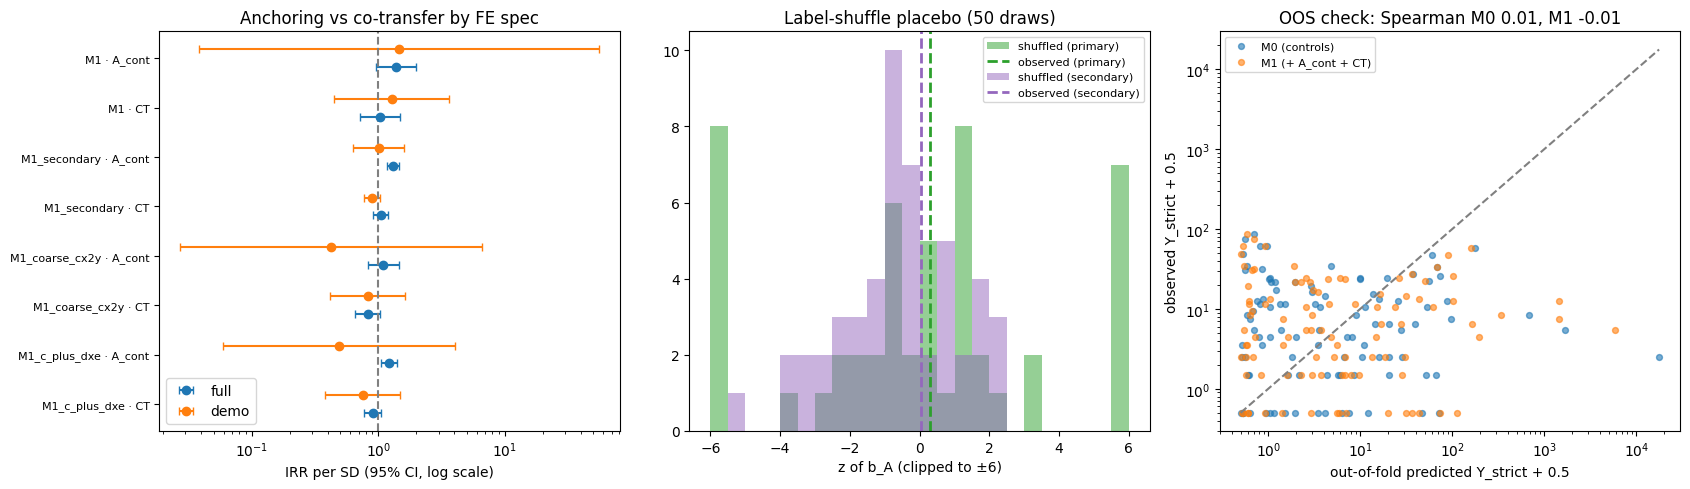

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) forest plot: IRR per SD, demo vs full run
ax = axes[0]
labels, ypos = [], 0
for i, r in cmp.iterrows():
    for src, col, off in (("full", "tab:blue", 0.18), ("demo", "tab:orange", -0.18)):
        est, lo, hi = r[f"{src}_irr_sd"], r[f"{src}_lo"], r[f"{src}_hi"]
        if est is None or not np.isfinite(est):
            continue
        ax.errorbar(est, ypos + off, xerr=[[est - lo], [hi - est]], fmt="o", color=col,
                    label=src if i == 0 else None, capsize=3)
    labels.append(f'{r["model"]} · {r["var"]}')
    ypos += 1
ax.axvline(1, color="grey", ls="--")
ax.set_xscale("log")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("IRR per SD (95% CI, log scale)")
ax.set_title("Anchoring vs co-transfer by FE spec")
ax.legend()

# (b) label-shuffle placebo z distribution vs observed z (co-primary secondary spec)
ax = axes[1]
for spec, col in (("primary", "tab:green"), ("secondary", "tab:purple")):
    z = ls_draws[f"z_A_{spec}"].dropna().clip(-6, 6)  # degenerate tiny-sample fits give huge |z|: clipped for display
    ax.hist(z, bins=np.linspace(-6, 6, 25), alpha=0.5, color=col, label=f"shuffled ({spec})")
    ax.axvline(placebo_summ[spec]["z_A_obs"], color=col, lw=2, ls="--", label=f"observed ({spec})")
ax.set_xlabel("z of b_A (clipped to ±6)")
ax.set_title(f"Label-shuffle placebo ({N_SHUFFLES} draws)")
ax.legend(fontsize=8)

# (c) out-of-fold predictions vs observed Y_strict
ax = axes[2]
ax.scatter(so.mu0 + 0.5, so.Y_strict + 0.5, s=18, alpha=0.6, label="M0 (controls)")
ax.scatter(so.mu1 + 0.5, so.Y_strict + 0.5, s=18, alpha=0.6, label="M1 (+ A_cont + CT)")
mx = float(max(so.Y_strict.max(), so.mu0.max(), so.mu1.max())) + 1
ax.plot([0.5, mx], [0.5, mx], color="grey", ls="--")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("out-of-fold predicted Y_strict + 0.5")
ax.set_ylabel("observed Y_strict + 0.5")
ax.set_title(f"OOS check: Spearman M0 {oos_res['spearman_M0']:.2f}, M1 {oos_res['spearman_M1']:.2f}")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()